In [1]:
import scanpy as sc
import pandas as pd

adata = sc.read_h5ad("GSE176078_annotated.h5ad")

print(adata)
adata.obs["celltype_broad"].value_counts()

AnnData object with n_obs × n_vars = 82954 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype_broad'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_broad_colors', 'hvg', 'leiden_colors', 'log1p', 'rank_genes_groups'
    obsm: 'X_umap'


celltype_broad
T cells              30586
Tumour epithelial    16987
Fibroblasts          10460
Macrophages           8471
Endothelial           6503
NK cells              5440
B cells               3295
Mesenchymal-like       886
Plasma cells           310
Dendritic cells         16
Name: count, dtype: int64

In [2]:
tcells = adata[adata.obs["celltype_broad"] == "T cells"].copy()
print(tcells)

AnnData object with n_obs × n_vars = 30586 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype_broad'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_broad_colors', 'hvg', 'leiden_colors', 'log1p', 'rank_genes_groups'
    obsm: 'X_umap'


C:\Users\annam\anaconda3\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


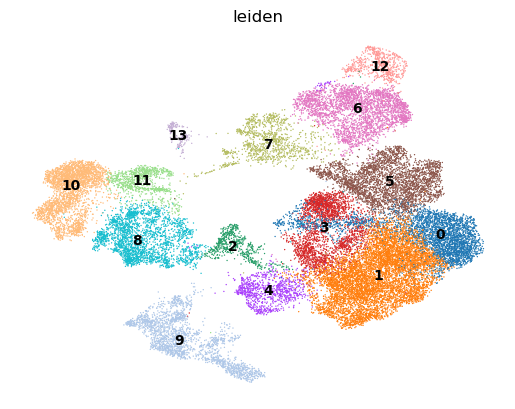

In [3]:
# Recalculate HVGs within T cells
sc.pp.highly_variable_genes(
    tcells,
    n_top_genes=2000
)

# Subset to T-cell HVGs
tcells_hvg = tcells[:, tcells.var["highly_variable"]].copy()

# Scale
sc.pp.scale(tcells_hvg, max_value=10)

# PCA
sc.tl.pca(tcells_hvg, svd_solver="arpack")

# Neighbours
sc.pp.neighbors(tcells_hvg, n_neighbors=15, n_pcs=20)

# UMAP
sc.tl.umap(tcells_hvg)

# Leiden clustering
sc.tl.leiden(
    tcells_hvg,
    resolution=0.4,
    flavor="igraph",
    directed=False,
    n_iterations=2
)

# Plot T-cell subclusters
sc.pl.umap(tcells_hvg, color="leiden", legend_loc="on data", frameon=False)

In [4]:
tcell_markers = [

    # General T-cell
    "CD3D", "CD3E",

    # CD4 helper / naïve
    "IL7R", "LTB", "MALAT1",

    # CD8 cytotoxic
    "CD8A", "CD8B", "CCL5", "NKG7", "GZMB",

    # Exhaustion
    "PDCD1", "CTLA4", "LAG3", "TIGIT",

    # Activation
    "IFNG", "HLA-DRA",

    # Regulatory T cells
    "FOXP3", "IL2RA",

    # Proliferation
    "MKI67", "TOP2A"
]

tcell_markers_present = [
    g for g in tcell_markers
    if g in tcells_hvg.var_names
]

print(tcell_markers_present)

['LTB', 'MALAT1', 'CD8A', 'CD8B', 'CCL5', 'NKG7', 'GZMB', 'CTLA4', 'LAG3', 'TIGIT', 'IFNG', 'HLA-DRA', 'FOXP3', 'IL2RA', 'MKI67', 'TOP2A']


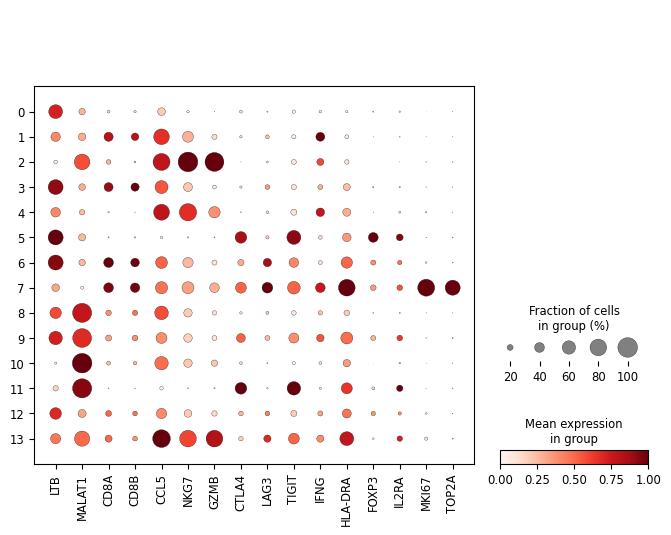

In [5]:
sc.pl.dotplot(
    tcells_hvg,
    var_names=tcell_markers_present,
    groupby="leiden",
    standard_scale="var"
)

In [6]:
tcell_annotation = {
    "0": "CD4 helper",
    "1": "Cytotoxic CD8",
    "2": "Activated cytotoxic",
    "3": "CD4 helper",
    "4": "Cytotoxic CD8",
    "5": "Exhausted/Treg-like",
    "6": "CD4 helper",
    "7": "Proliferating exhausted",
    "8": "CD4 helper",
    "9": "CD4 helper",
    "10": "CD4 helper",
    "11": "Treg-like",
    "12": "Activated helper",
    "13": "Activated cytotoxic"
}

In [7]:
tcells_hvg.obs["tcell_state"] = (
    tcells_hvg.obs["leiden"]
    .map(tcell_annotation)
)

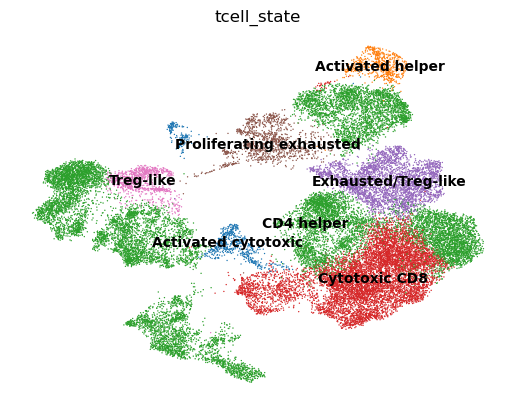

In [8]:
sc.pl.umap(
    tcells_hvg,
    color="tcell_state",
    legend_loc="on data",
    frameon=False
)

In [9]:
# Subset macrophages from annotated dataset 2
macs = adata[
    adata.obs["celltype_broad"] == "Macrophages"
].copy()

print(macs)

AnnData object with n_obs × n_vars = 8471 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype_broad'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_broad_colors', 'hvg', 'leiden_colors', 'log1p', 'rank_genes_groups'
    obsm: 'X_umap'


C:\Users\annam\anaconda3\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


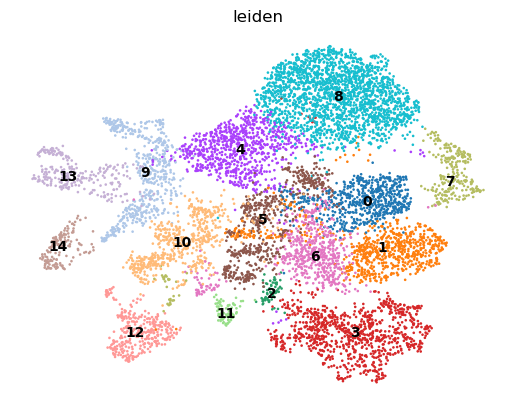

In [11]:
# Recalculate HVGs within macrophages
sc.pp.highly_variable_genes(
    macs,
    n_top_genes=2000
)

# Subset to macrophage HVGs
macs_hvg = macs[:, macs.var["highly_variable"]].copy()

# Scale
sc.pp.scale(macs_hvg, max_value=10)

# PCA
sc.tl.pca(macs_hvg, svd_solver="arpack")

# Neighbors
sc.pp.neighbors(
    macs_hvg,
    n_neighbors=15,
    n_pcs=20
)

# UMAP
sc.tl.umap(macs_hvg)

# Leiden clustering
sc.tl.leiden(
    macs_hvg,
    resolution=0.4,
    flavor="igraph",
    directed=False,
    n_iterations=2
)

# Plot macrophage clusters
sc.pl.umap(
    macs_hvg,
    color="leiden",
    legend_loc="on data",
    frameon=False
)

In [12]:
mac_markers = [

    # Core macrophage/myeloid
    "LST1", "LYZ", "C1QA", "C1QB",
    "FCER1G", "TYROBP",

    # Inflammatory / M1-like
    "IL1B", "TNF", "CXCL8",
    "CXCL10", "NFKBIA",

    # M2 / TAM-like
    "CD163", "MRC1", "MSR1",
    "APOE", "MERTK",

    # Antigen presentation
    "HLA-DRA", "HLA-DPB1", "CD74",

    # Proliferation
    "MKI67", "TOP2A"
]

mac_markers_present = [
    g for g in mac_markers
    if g in macs_hvg.var_names
]

print(mac_markers_present)

['LYZ', 'C1QA', 'IL1B', 'TNF', 'CXCL8', 'CXCL10', 'APOE', 'HLA-DRA', 'MKI67', 'TOP2A']


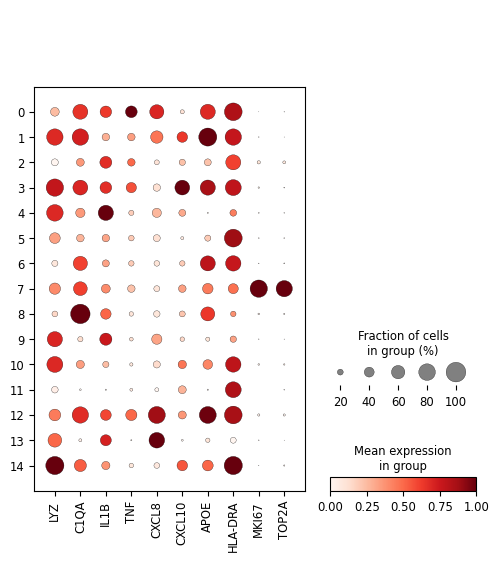

In [13]:
sc.pl.dotplot(
    macs_hvg,
    var_names=mac_markers_present,
    groupby="leiden",
    standard_scale="var"
)

In [14]:
mac_annotation = {

    "0": "Inflammatory macrophage",
    "1": "TAM-like macrophage",
    "2": "Macrophage",
    "3": "APC-like macrophage",
    "4": "Inflammatory macrophage",
    "5": "APC-like macrophage",
    "6": "TAM-like macrophage",
    "7": "Proliferating macrophage",
    "8": "Macrophage",
    "9": "Inflammatory macrophage",
    "10": "APC-like macrophage",
    "11": "Macrophage",
    "12": "TAM-like macrophage",
    "13": "Inflammatory macrophage",
    "14": "APC-like macrophage"
}

In [15]:
macs_hvg.obs["macrophage_state"] = (
    macs_hvg.obs["leiden"]
    .map(mac_annotation)
)

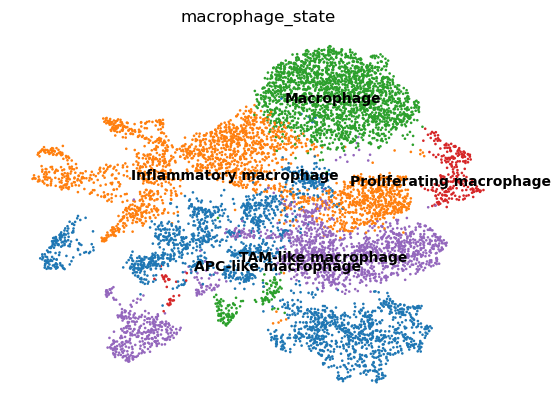

In [16]:
sc.pl.umap(
    macs_hvg,
    color="macrophage_state",
    legend_loc="on data",
    frameon=False
)

In [17]:
tcells_hvg.write("GSE176078_tcells_annotated.h5ad")
macs_hvg.write("GSE176078_macrophages_annotated.h5ad")